# Unsupervised Text Clustering Pipeline: 20 Newsgroups
This notebook encapsulates the **Data Acquisition, Exploratory Data Analysis (EDA), Data Sanitization, and Splitting** phases of our text clustering pipeline. The primary purpose is to profile the underlying text features and prepare clean text arrays for dense and sparse vectorization.

### Objectives:
1. Parse raw unstructured Usenet articles and structure them into dataframes.
2. Analyze class distributions to measure data balance.
3. Clean raw strings (strip numeric debris, extra whitespaces, normalize casing).
4. Remove semantic non-contributors (stopwords) and apply lemmatization.
5. Isolate distinct Train, Validation, and Test partitions tracking baseline class stratifications.

---

### Project Architecture Note:
> **Experimental Phase vs. Production Code:** > This notebook is dedicated exclusively to the **Exploration and Model Trials phase** (Data profiling, quick iterations, and baseline experiments). 
> 
> Once the optimal pipeline configurations (best text preprocessing rules, text embeddings, and clustering hyperparameters) are identified and validated across these notebooks, the final logic will be refactored into modular, production-ready Python scripts inside the `/src` directory. This modular code will then serve as the backend for the deployment phase.
---

## 1. Dependency Rationale

Before manipulating our text corpus, we initialize the chosen libraries form the foundation of our traditional NLP preprocessing strategy

In [1]:
import os
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 2. Raw Data Ingestion & Integrity Verification

In this section, we establish our persistent data layer by downloading the complete 20 Newsgroups corpus and verifying its structural integrity. 

We format the raw arrays into a `pandas.DataFrame`

In [ ]:



path = os.path.join("..","..", "data", "raw")

newsgroups_data = fetch_20newsgroups(subset='all', 
remove=('headers', 'footers', 'quotes'), data_home=path)

df_news = pd.DataFrame({
    'text': newsgroups_data.data,
    'target': newsgroups_data.target,
    'target_name': [newsgroups_data.target_names[t] for t in newsgroups_data.target]
})

csv_destination = os.path.join(path, "newsgroups_raw.csv")
df_news.to_csv(csv_destination, index=False)


In [ ]:
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))

path = os.path.join(
    base_dir,
    "data/raw/newsgroups_raw.csv"
                    )
df = pd.read_csv(path)

display(df.head())
print(df.columns)
print(df.shape)

,text,target,target_name
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


Index(['text', 'target', 'target_name'], dtype='object')
(18846, 3)


# 3. Data Partitioning & Class Distribution Analysis

To build a rigorous testing pipeline and simulate real-world data constraints, we isolate our combined matrix into three stratified partitions: **Training (80%)**, **Validation (10%)**, and **Testing (10%)**. 


###  Exploratory Data Analysis Insights:
By auditing the final class distribution (`value_counts()`) on the training matrix, we evaluate the dataset's density profiles:
1. **Homogeneous Density**: The underlying classes are exceptionally well-balanced. Target groups maintain a stable volume ceiling near $\sim 800$ articles (e.g., sports/science subcategories) and drop gently to a baseline floor of $\sim 500$ documents for smaller discussion categories (e.g., religion/politics).
2. **Impact on Clustering**: Since unsupervised algorithms (like K-Means or GMM) assume uniform cluster distributions and are highly sensitive to massive scale imbalances, this well-distributed class profile provides strong structural stability for our distance metrics downstream.

In [3]:
df_train, df_temp = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['target']
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=42, stratify=df_temp['target']
)

print(f"Train dataset size: {df_train.shape[0]} articles")
print(f"Val dataset size: {df_val.shape[0]} articles")
print(f"Test dataset size: {df_test.shape[0]} articles")

Train dataset size: 15076 articles
Val dataset size: 1885 articles
Test dataset size: 1885 articles


In [4]:
df_train['target_name'].value_counts()

target_name
rec.sport.hockey            799
soc.religion.christian      798
rec.motorcycles             797
rec.sport.baseball          795
sci.crypt                   793
rec.autos                   792
sci.med                     792
comp.windows.x              790
sci.space                   790
comp.os.ms-windows.misc     788
sci.electronics             787
comp.sys.ibm.pc.hardware    786
misc.forsale                780
comp.graphics               778
comp.sys.mac.hardware       770
talk.politics.mideast       752
talk.politics.guns          728
alt.atheism                 639
talk.politics.misc          620
talk.religion.misc          502
Name: count, dtype: int64

# 4. Exploratory Data Analysis: Text Profiling & Structural Audit

Before applying any data sanitization functions, we perform a deep qualitative and quantitative audit of our training text partition. This combining step bridges direct empirical observation of raw text formats with a statistical review of word lengths.

### Analysis Pillars:
1. **Qualitative Inspection**: Sampling random documents to analyze human writing styles, noise components, and structural debris.
2. **Class Balance Verification**: Confirming categorical density bounds across the training set.
3. **Volumetric Length Profiling**: Capturing word-count boundaries to identify structural anomalies and long-tail constraints.

---

### Core Analytical Insights:

* **Corpus Density Profile**: As visualized in our categorical bar plot, the dataset shows strong structural stability. The training partition displays a highly uniform class density with no single dominant group, eliminating major class-imbalance concerns for our downstream unsupervised distance metrics.

* **Qualitative Noise Extraction Targets**: 
  Our direct text preview (Documents 1 & 2) reveals specific non-semantic noise elements that must be structurally pruned:
  1. *Syntactic Debris:* Isolated enumeration tokens (e.g., `a)`, `b)`, `c)`) and punctuation clusters (`-`, `:`, `,`).
  2. *Formatting Overhead:* Trailing line breaks (`\n`), irregular tab spaces (`\t`), and single character residues that inflate features without providing semantic topical value.

* **The Extreme Long-Tail Challenge (Statistical Breakdown)**:
  The word count distribution presents a massive statistical right-skew:
  * **Core Concentration:** $50\%$ of all articles (`median`) contain $83$ words or fewer, and $75\%$ drop below $167$ words.
  * **The Outlier Flare:** The average count (`mean`) sits higher at $\sim 184$ words due to severe trailing outliers, peaking at an absolute maximum of **$11,766$ words** for a single document.

* **Impact on Embeddings & Modeling**:
  1. *For Sparse Vectorization (TF-IDF):* The vast length variance implies that raw vocabulary sizes will explode if left untreated. Text normalization (Stopwords + Lemmatization) is mandatory to compress this feature space.
  2. *For Dense Vectorization (Transformers/BERT):* Knowing that the 75th percentile is only $167$ words tells us that a standard model sequence length (like `max_length=256` or `512`) will capture almost all document contents completely without severe truncation loss, while preventing severe memory overhead from the $11,766$-word outliers.

In [5]:
for i in range(2):
    print(f"--- Document {i+1} ---")
    print(df_train['text'].iloc[i])
    print(df_train['target_name'].iloc[i])
    print("-" * 50)

--- Document 1 ---
No doubt this is an old question, but I didn't find the answer in the
FAQs I could find, so - here goes:

I have a Sunview application that I want to convert to X (OpenLook,
Motiv, whatever). I remember hearing quite some time ago that there
are tools to accomplish this task.

	a) is that so?
	b) are they public domain?
	c) any good, i.e.
	d) advantages over reimplementing the interface myself?

Thanks,
comp.windows.x
--------------------------------------------------
--- Document 2 ---
Try this one, a favorite around here:

Bureau of Assholes, Tightwads, and Facists.

And remember, they were created by the Infernal Revenue Code.

			--msa


talk.politics.guns
--------------------------------------------------


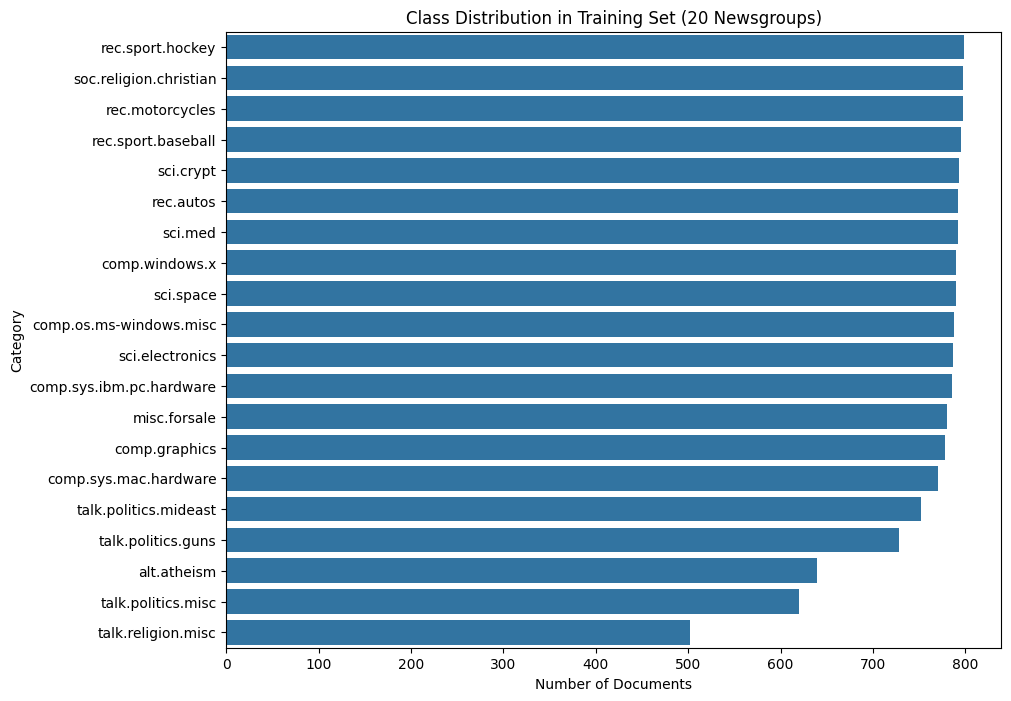

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x=df_train['target_name'].value_counts().values,
    y=df_train['target_name'].value_counts().index,
    orient='h'
)
plt.title('Class Distribution in Training Set (20 Newsgroups)')
plt.xlabel('Number of Documents')
plt.ylabel('Category')
plt.show()

In [7]:
df_train['word_count_raw'] = df_train['text'].apply(lambda x: len(str(x).split()))

print("--- Word Count Stats (Before Cleaning) ---")
print(df_train['word_count_raw'].describe())



--- Word Count Stats (Before Cleaning) ---
count    15076.000000
mean       183.879345
std        506.018806
min          0.000000
25%         40.000000
50%         83.000000
75%        167.000000
max      11765.000000
Name: word_count_raw, dtype: float64


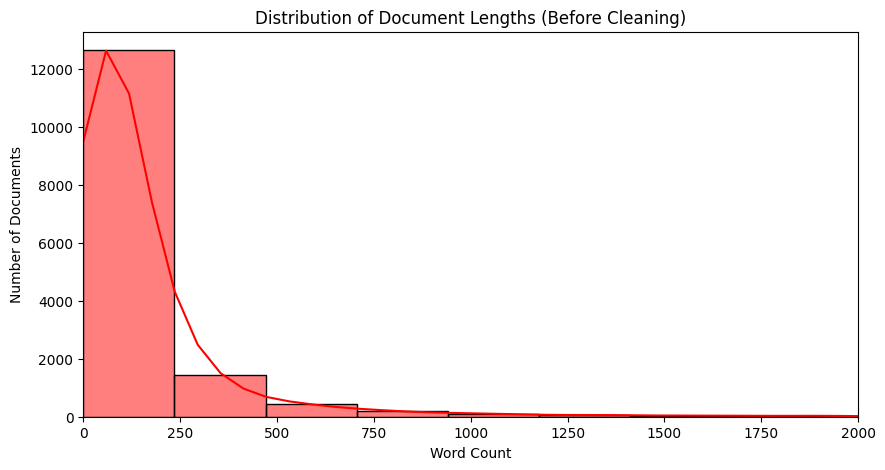

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count_raw'], bins=50, kde=True, color='red')
plt.title('Distribution of Document Lengths (Before Cleaning)')
plt.xlabel('Word Count')
plt.ylabel('Number of Documents')
plt.xlim(0, 2000)
plt.show()

# 5. Data Cleansing & Morphological Normalization Pipeline

This section implements our core deterministic text preprocessing pipeline. Based on our empirical text audit, we execute statistical trimming followed by a sequential linguistic optimization sequence to convert raw strings into highly representative semantic tokens.

### Pipeline Stage 1: Initial Volumetric Trimming
Before parsing strings, we isolate our training core by enforcing `word_count_raw >= 1` and `<= 2000` to completely drop empty interactions and isolate the extreme right-tail outliers ($>2000$ words) that would otherwise skew our cluster variance bounds.

### Pipeline Stage 2: The Preprocessing Architecture
We build a dedicated function (`preprocess_text`) executing the following steps sequentially:
1. **Case Normalization:** Casting all characters to `.lower()`.
2. **Contraction Expansion:** Mapping short-form inflections (e.g., `didn't` $\rightarrow$ `did not`) using an pre-compiled regular expression dictionary to preserve accurate text syntax.
3. **Regex Debris Sanitization:**
   * Stripping email signatures and routing paths (`\S+@\S+`).
   * Erasing explicit Hex/ASCII byte noise (e.g., `\x[0-9a-fA-F]{2}`) left over from newsgroup file encoding headers.
   * Dropping URLs (`http/www`) and structural web dividers (`|||`).
4. **Linguistic Refinement:** Eliminating generic functional words (`nltk.corpus.stopwords`) and dropping short tokens (`len(word) > 2`) to strip out uninformative single/double character noise (like the `a)`, `b)` markers seen in the raw text).
5. **Lemmatization:** Employing `WordNetLemmatizer` to dynamically reduce inflected word variations down to their canonical dictionary roots.

---

### Post-Preprocessing Analytical Insights & Verification:

#### 1. Empirical Text Simplification:
Looking at our direct output comparison (Document 1):
* **Original:** Contained structural noise, itemization indicators (`a)`, `b)`), short auxiliary verbs (`is`, `that`, `they`), and punctuation blocks.
* **Processed:** Successfully compressed into a sequence of high-density semantic targets (`doubt old question find answer faq...`).

#### 2. Statistical Vocabulary Compression (Before vs. After):
Comparing our pre-cleaning and post-cleaning statistical profiles yields highly valuable insights for downstream modeling:
* **The Variance Drop:** The standard deviation (`std`) of document lengths dropped drastically from **$506.0$ down to $114.0$** words. This indicates a massive stabilization of data density across the corpus.
* **The Scale Shift:** The average document length (`mean`) compressed from **$183.8$ down to $74.1$** words, and the median length (`50%`) moved from **$83$ down to $41$** words. This represents a $\sim 50\%$ structural reduction in input volume while preserving core keyword representations.
* **Vocabulary Efficiency:** By dropping non-semantic features, we directly combat the **Curse of Dimensionality**, meaning our TF-IDF sparse matrix and dense vectors will be much more memory-efficient and structurally stable during K-Means/GMM clustering trials.

#### 3. Post-Cleaning Empty Document Evacuation:
Because stripping stopwords and numbers can sometimes reduce exceptionally short text snippets into entirely empty strings, we run a final clean-up validation pass:
* We drop fully-evacuated documents (`word_count_cleaned >= 1`).
* **Final Split Quantities:**
  * **Train Set:** $14,518$ optimized, verified text objects.
  * **Validation Set:** $1,819$ aligned tracking components.
  * **Test Set:** $1,817$ independent test instances.

In [9]:
df_train = df_train[(df_train['word_count_raw'] >= 1) & (df_train['word_count_raw'] <= 2000)]
# df_train = df_train[(df_train['word_count_raw'] >= 1)]

In [10]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

contractions = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot",
    "couldn't": "could not", "could've": "could have", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "had've": "had have", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is", 
    "how'd": "how did", "how'll": "how will", "how's": "how is", 
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have", 
    "isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is",
    "let's": "let us", "mayn't": "may not", "might've": "might have", 
    "mightn't": "might not", "must've": "must have", "mustn't": "must not", 
    "needn't": "need not", "shan't": "shall not", "she'd": "she would", 
    "she'll": "she will", "she's": "she is", "should've": "should have", 
    "shouldn't": "should not", "that'd": "that would", "that's": "that is", 
    "there'd": "there would", "there's": "there is", "they'd": "they would", 
    "they'll": "they will", "they're": "they are", "they've": "they have", 
    "wasn't": "was not", "we'd": "we would", "we'll": "we will", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what'll": "what will", 
    "what're": "what are", "what's": "what is", "what've": "what have", 
    "when's": "when is", "where'd": "where did", "where's": "where is", 
    "who'll": "who will", "who's": "who is", "who've": "who have", 
    "why's": "why is", "won't": "will not", "would've": "would have", 
    "wouldn't": "would not", "y'all": "you all", "you'd": "you would", 
    "you'll": "you will", "you're": "you are", "you've": "you have"
}

contractions_pattern = re.compile(
    r'\b(' + '|'.join(map(re.escape, contractions.keys())) + r')\b', 
    re.IGNORECASE
)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    
    text = contractions_pattern.sub(lambda x: contractions[x.group()], text)

    text = re.sub(r'\S+@\S+', ' ', text)

    text = re.sub(r'\\x[0-9a-fA-F]{2}', ' ', text)
    text = re.sub(r'(?<![a-zA-Z])x[0-9][0-9a-fA-F]', ' ', text)
    text = text.encode("ascii", "ignore").decode("ascii")

    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)

    text = re.sub(r':[\w]+:', ' ', text)           
    text = re.sub(r'\|\|\|', ' ', text) 

    text = re.sub(r'[^a-z\s]', ' ', text)  
   
    text = " ".join(
        [
            lemmatizer.lemmatize(word)
            for word in text.split()
            if word not in stop_words and len(word) > 2
        ]
    )
    
    text = re.sub(r"\s+", " ", text).strip()

    return text




In [ ]:

df_train['cleaned_text'] = df_train['text'].apply(preprocess_text)


In [12]:
for i in range(1):
    print(f"--- Document {i+1} ---")
    print("Original: \n" ,df_train['text'].iloc[i])
    print("-" * 50)
    print("After processing: \n", df_train['cleaned_text'].iloc[i])
    print("-" * 50)
    print("Target Name: \n", df_train['target_name'].iloc[i])
    print("-" * 50)

--- Document 1 ---
Original: 
 No doubt this is an old question, but I didn't find the answer in the
FAQs I could find, so - here goes:

I have a Sunview application that I want to convert to X (OpenLook,
Motiv, whatever). I remember hearing quite some time ago that there
are tools to accomplish this task.

	a) is that so?
	b) are they public domain?
	c) any good, i.e.
	d) advantages over reimplementing the interface myself?

Thanks,
--------------------------------------------------
After processing: 
 doubt old question find answer faq could find go sunview application want convert openlook motiv whatever remember hearing quite time ago tool accomplish task public domain good advantage reimplementing interface thanks
--------------------------------------------------
Target Name: 
 comp.windows.x
--------------------------------------------------


In [13]:
df_train['word_count_cleaned'] = df_train['cleaned_text'].apply(lambda x: len(str(x).split()))

print("--- Word Count Stats (After Cleaning) ---")
print(df_train['word_count_cleaned'].describe())


--- Word Count Stats (After Cleaning) ---
count    14850.000000
mean        74.123636
std        114.088510
min          0.000000
25%         20.000000
50%         41.000000
75%         81.000000
max       2279.000000
Name: word_count_cleaned, dtype: float64


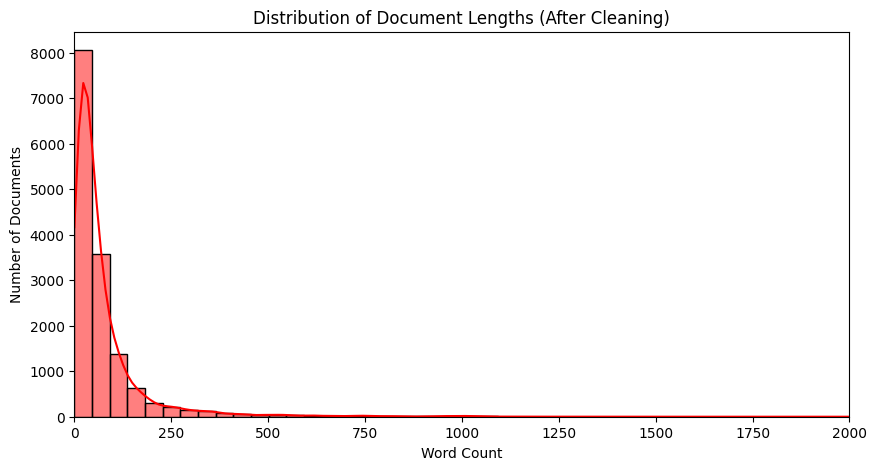

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count_cleaned'], bins=50, kde=True, color='red')
plt.title('Distribution of Document Lengths (After Cleaning)')
plt.xlabel('Word Count')
plt.ylabel('Number of Documents')
plt.xlim(0, 2000)
plt.show()

In [16]:
df_train = df_train[df_train['word_count_cleaned'] >= 1]

print("New minimum length:", df_train['word_count_cleaned'].min())
print("Final training set size:", df_train.shape[0])



New minimum length: 1
Final training set size: 14518


In [17]:
df_val['cleaned_text'] = df_val['text'].apply(preprocess_text)
df_test['cleaned_text'] = df_test['text'].apply(preprocess_text)

df_val['word_count_cleaned'] = df_val['cleaned_text'].apply(lambda x: len(str(x).split()))
df_test['word_count_cleaned'] = df_test['cleaned_text'].apply(lambda x: len(str(x).split()))

# 3. Filter empty rows and extreme outliers (same rules as Train)
df_val = df_val[(df_val['word_count_cleaned'] >= 1) & (df_val['word_count_cleaned'] <= 2279)]
df_test = df_test[(df_test['word_count_cleaned'] >= 1) & (df_test['word_count_cleaned'] <= 2279)]

print(f"Final Val set size:  {df_val.shape[0]} documents")
print(f"Final Test set size: {df_test.shape[0]} documents")

Final Val set size:  1819 documents
Final Test set size: 1817 documents


## Save cleaned data

In [ ]:
processed_path = os.path.abspath(os.path.join("..", "..", "data", "processed"))

# Save to CSV
df_train.to_csv(os.path.join(processed_path, "train_processed.csv"), index=False)
df_val.to_csv(os.path.join(processed_path, "val_processed.csv"), index=False)
df_test.to_csv(os.path.join(processed_path, "test_processed.csv"), index=False)

print("All processed splits saved successfully!")

All processed splits saved successfully!
